In [1]:
import pandas as pd
import pm4py
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Pfad zur XES-Datei
FILE_PATH = "/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/BPI Challenge 2017_1_all/BPI Challenge 2017.xes.gz"
log_df = pm4py.read_xes(FILE_PATH)


/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/.venv/lib/python3.13/site-packages/pm4py/utils.py:991: UserWarning: Install the optional requirement `rustxes` to import/export files faster.
  warnings.warn("Install the optional requirement `rustxes` to import/export files faster.")
/Users/titusthamm/Library/Mobile Documents/com~apple~CloudDocs/Masterstudium/3. Semester/Praktikum/1. Assignment/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 31509/31509 [00:18<00:00, 1722.35it/s]


In [7]:
#Gruppieren nach Fall und finde Start-Zeitpunkt
case_starts = log_df[log_df['concept:name'] == 'A_Create Application'].groupby('case:concept:name')['time:timestamp'].min()

# Berechne Trace Length (Anzahl Events) pro Fall
print("Berechne Trace Length pro Fall")
trace_lengths = log_df.groupby('case:concept:name').size()

# Erstelle DataFrame mit Case Start Time und Trace Length
case_data = pd.DataFrame({
    'case_start_time': case_starts,
    'trace_length': trace_lengths
}).reset_index()

# Entferne Fälle ohne Start-Zeitpunkt
case_data = case_data.dropna(subset=['case_start_time'])
print(f"{len(case_data):,} Fälle mit Start-Zeitpunkt")

# Statistiken
print(f"Trace Length Statistiken")
print(f"  Mean:   {case_data['trace_length'].mean():.2f} Events")
print(f"  Median: {case_data['trace_length'].median():.2f} Events")
print(f"  Min:    {case_data['trace_length'].min()} Events")
print(f"  Max:    {case_data['trace_length'].max()} Events")
print(f"  Std:    {case_data['trace_length'].std():.2f} Events")


Berechne Trace Length pro Fall
31,509 Fälle mit Start-Zeitpunkt
Trace Length Statistiken
  Mean:   38.16 Events
  Median: 35.00 Events
  Min:    10 Events
  Max:    180 Events
  Std:    16.72 Events


In [3]:
if case_data['case_start_time'].dt.tz is not None:
    end_date = pd.Timestamp('2016-12-31 23:59:59', tz=case_data['case_start_time'].dt.tz)
else:
    end_date = pd.Timestamp('2016-12-31 23:59:59')

case_data_filtered = case_data[case_data['case_start_time'] <= end_date].copy()
print(f"Gefilterte Fälle bis Ende Dezember 2016: {len(case_data_filtered):,} von {len(case_data):,}")

# Erstelle monatliche Bins basierend auf case_start_time
case_data_filtered['year_month'] = case_data_filtered['case_start_time'].dt.to_period('M')
case_data_filtered['year_month_str'] = case_data_filtered['year_month'].astype(str)

# Gruppiere nach Monat und berechne Statistiken
monthly_stats = case_data_filtered.groupby('year_month_str').agg({
    'trace_length': ['mean', 'std', 'count']
}).reset_index()
monthly_stats.columns = ['month', 'mean_trace_length', 'std_trace_length', 'case_count']

# Sortiere nach Monat
monthly_stats['month_date'] = pd.to_datetime(monthly_stats['month'])
monthly_stats = monthly_stats.sort_values('month_date').reset_index(drop=True)


print(monthly_stats[['month', 'mean_trace_length', 'std_trace_length', 'case_count']].to_string(index=False))



Gefilterte Fälle bis Ende Dezember 2016: 31,509 von 31,509
  month  mean_trace_length  std_trace_length  case_count
2016-01          39.901094         17.324214        2194
2016-02          37.924959         16.881776        2412
2016-03          37.389976         16.193109        2454
2016-04          38.822232         18.136257        2177
2016-05          41.041103         19.196077        2068
2016-06          39.713429         17.263406        3001
2016-07          37.485357         15.310922        3039
2016-08          36.765316         15.318835        3085
2016-09          36.512163         15.571034        3042
2016-10          37.122204         15.971326        2995
2016-11          38.411435         16.729715        2676
2016-12          38.269653         17.266717        2366


/var/folders/nr/tnxq3hk97cgdl4zw5lsqck3r0000gn/T/ipykernel_94634/1304680419.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  case_data_filtered['year_month'] = case_data_filtered['case_start_time'].dt.to_period('M')


In [4]:
# Filtere nur 2016 Daten
case_data_2016 = case_data[case_data['case_start_time'].dt.year == 2016].copy()

# Teile in erste Hälfte (Jan-Jun) und zweite Hälfte (Jul-Dec)
case_data_2016['half'] = case_data_2016['case_start_time'].dt.month.apply(
    lambda x: 'First Half' if x <= 6 else 'Second Half'
)

# Trace Lengths für beide Hälften
first_half = case_data_2016[case_data_2016['half'] == 'First Half']['trace_length']
second_half = case_data_2016[case_data_2016['half'] == 'Second Half']['trace_length']

print(f"Beschreibende Statistiken")
print(f"Erste Hälfte 2016 (Jan-Jun):")
print(f"  Anzahl Fälle: {len(first_half):,}")
print(f"  Mean:  {first_half.mean():.2f} Events")
print(f"  Std:   {first_half.std():.2f} Events")
print(f"  Median: {first_half.median():.2f} Events")

print(f"Zweite Hälfte 2016 (Jul-Dec):")
print(f"  Anzahl Fälle: {len(second_half):,}")
print(f"  Mean:  {second_half.mean():.2f} Events")
print(f"  Std:   {second_half.std():.2f} Events")
print(f"  Median: {second_half.median():.2f} Events")


Beschreibende Statistiken
Erste Hälfte 2016 (Jan-Jun):
  Anzahl Fälle: 14,306
  Mean:  39.10 Events
  Std:   17.50 Events
  Median: 35.00 Events
Zweite Hälfte 2016 (Jul-Dec):
  Anzahl Fälle: 17,203
  Mean:  37.37 Events
  Std:   15.99 Events
  Median: 34.00 Events


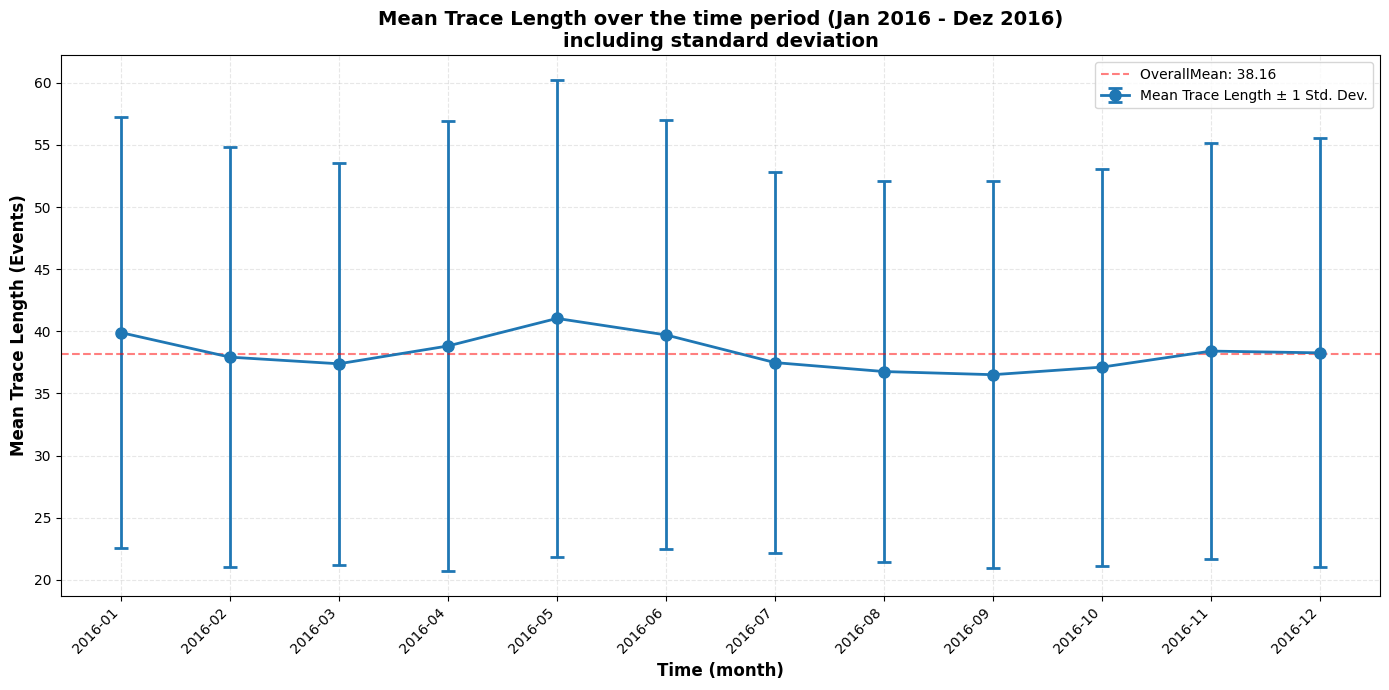

In [5]:
# Erstelle Visualisierung
plt.figure(figsize=(14, 7))

# Plot mit Error Bars
x_pos = range(len(monthly_stats))
plt.errorbar(
    x_pos,
    monthly_stats['mean_trace_length'],
    yerr=monthly_stats['std_trace_length'],
    marker='o',
    linestyle='-',
    capsize=5,
    capthick=2,
    linewidth=2,
    markersize=8,
    label='Mean Trace Length ± 1 Std. Dev.'
)

# Labels und Formatierung
plt.xlabel('Time (month)', fontsize=12, fontweight='bold')
plt.ylabel('Mean Trace Length (Events)', fontsize=12, fontweight='bold')
plt.title('Mean Trace Length over the time period (Jan 2016 - Dez 2016)\nincluding standard deviation', fontsize=14, fontweight='bold')
plt.xticks(x_pos, monthly_stats['month'], rotation=45, ha='right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=10)

# Zusätzliche Linie für Gesamt-Mean (nur gefilterte Daten)
overall_mean = case_data_filtered['trace_length'].mean()
plt.axhline(y=overall_mean, color='r', linestyle='--', alpha=0.5, label=f'OverallMean: {overall_mean:.2f}')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()
